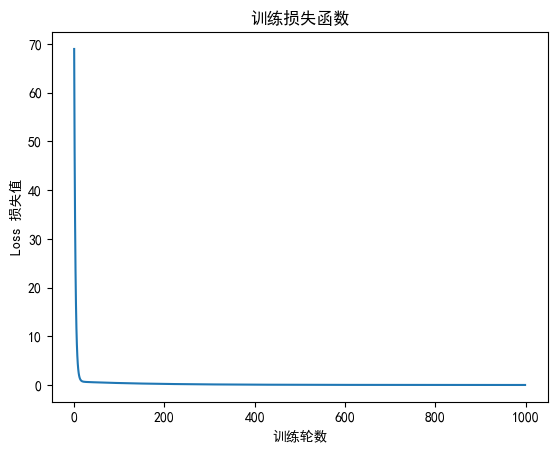

In [5]:
# =====================================
# 1.导入需要的工具包
# =====================================
import torch
import matplotlib.pyplot as plt # 画图工具：画损失下降曲线
# 解决中文乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# =====================================
# 2.准备训练数据
# 我们要让AI学习：y = 2x + 3
# =====================================


# 输入数据x
x = torch.tensor([1.0, 2.0, 3.0, 4.0])

# 真实标签 y_true(标准答案)
y_true = torch.tensor([5.0, 7.0, 9.0, 11.0])

# =====================================
# 3. 初始化模型参数(需要被训练的变量)
# W是权重，b是偏置
# requires_grad=True 开启自动求导，这两个数要被AI不断更新
# =====================================
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
#======================================
# 4.设置训练超参数(人手动设定的参数)
# =====================================
learning_rate = 0.01 # 学习率：控制每次更新步子大小
epoch_num = 1000 #训练轮数：整个数据集看1000遍
# =====================================
# 5. 选择优化器(用来自动更新w和b)
# SGD = 随机梯度下降
# 传入要更新的参数[w, b] + 学习率
# =====================================
optimizer = torch.optim.SGD([w, b], lr=learning_rate)
# =====================================
# 6.开始训练循环(最核心! )
# =====================================


loss_history = [] # 用来保存每一轮的损失，方便画图

for epoch in range(epoch_num): # 循环 epoch_num次
# -------------------------------------
# 步骤1：梯度清零；不清零梯度会累积，导致训练崩溃
# -------------------------------------
    optimizer.zero_grad()


# -------------------------------------
# 步骤2：前向传播
# 用当前 w 和 b 计算预测值 y_pred
# 模型: y = w * x + b
    y_pred = w * x + b

# -------------------------------------
# 步骤3：计算损失(误差)
# MSE均方误差：预测值和标准答案差距多大
# -------------------------------------
    loss = torch.mean((y_pred - y_true) ** 2)


# -------------------------------------
# 步骤4：反向传播
# 自动计算 w 和 b 的梯度
# 告诉每个参数“：往哪个方向改能让误差变小
# -------------------------------------
    loss.backward()


# -------------------------------------
# 步骤5:更新参数
# 优化器根据梯度，自动修改 w 和 b 
# -------------------------------------
    optimizer.step()

# -------------------------------------
# 记录损失值(画图用)
# -------------------------------------
    loss_history.append(loss.item())


# -------------------------------------
# 每100轮打印一次结果
# -------------------------------------
if epoch % 100 == 0:
    print(f"第{epoch:03d}轮 | 损失={loss.item():.4f} | w={w.item():.4f} | b={b.item():.4f}")

# =====================================
# 8.画损失下降曲线(直观看到AI在进步)
# =====================================
plt.plot(loss_history)            #plt:画图工具
plt.title("训练损失函数")          #plot:画线     #title:大标题
plt.xlabel("训练轮数")
plt.ylabel("Loss 损失值")
plt.show()  #弹出图


